In [1]:
import pandas as pd 
import numpy as np
df = pd.read_csv("/kaggle/input/datasets/ridwanul02/fake-and-real-news/fake_and_real_news.csv")
df.shape

(9900, 2)

In [2]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


In [4]:
df.describe()

,Text,label
count,9900,9900
unique,9865,2
top,Highlights: The Trump presidency on April 13 a...,Fake
freq,8,5000


In [5]:
df.dtypes

Text     object
label    object
dtype: object

In [6]:
df.isnull().sum()

Text     0
label    0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 35


In [8]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.head(35))

                                                   Text label
1576  Highlights: The Trump presidency on April 13 a...  Real
2173  Trump asks Supreme Court to block travel ban r...  Real
2887  Trump tries to rally support for healthcare bi...  Real
3330  Highlights: The Trump presidency on March 31 a...  Real
3401  Highlights: The Trump presidency on April 26 a...  Real
3432  Former Trump security aide was Russia blackmai...  Real
3861  Highlights: The Trump presidency on April 13 a...  Real
4123  Highlights: The Trump presidency on March 31 a...  Real
4525  'Nuclear option' fallout? More extreme U.S. ju...  Real
4727  Highlights: The Trump presidency on April 21 a...  Real
4867  Under pressure from Trump, Price resigns as he...  Real
5233  Highlights: The Trump presidency on April 13 a...  Real
5571  Trump Jr. emails suggest he welcomed Russian h...  Real
5892  Two ex-Trump aides charged in Russia probe, th...  Real
6114  Highlights: The Trump presidency on April 21 a...  Real
6165  Pe

In [9]:
df=df.drop_duplicates()

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.shape

(9865, 2)

In [12]:
df['label'].value_counts()

label
Fake    5000
Real    4865
Name: count, dtype: int64

In [13]:
df['label'].value_counts(normalize = True) *100

label
Fake    50.684237
Real    49.315763
Name: proportion, dtype: float64

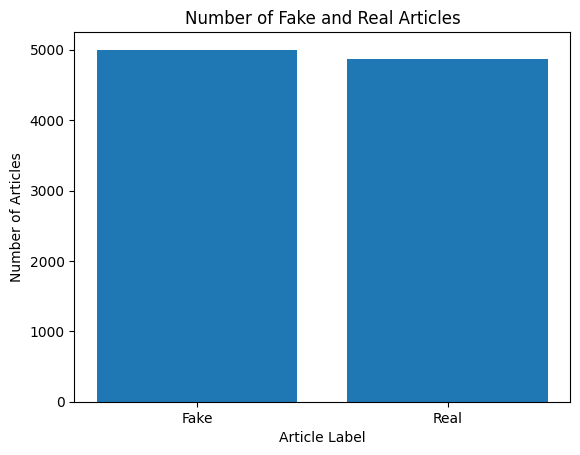

In [14]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.bar(label_counts.index, label_counts.values)

plt.title('Number of Fake and Real Articles')
plt.xlabel('Article Label')
plt.ylabel('Number of Articles')

plt.show()

In [15]:
df['word_count'] = df['Text'].str.split().str.len()
print(df['word_count'])

0       279
1       116
2       989
3       364
4       594
       ... 
9895    535
9896    328
9897    700
9898    439
9899    780
Name: word_count, Length: 9865, dtype: int64


In [16]:
print(df.groupby('label')['word_count'].mean())
print(df.groupby('label')['word_count'].median())


label
Fake    449.408800
Real    394.926413
Name: word_count, dtype: float64
label
Fake    419.0
Real    381.0
Name: word_count, dtype: float64


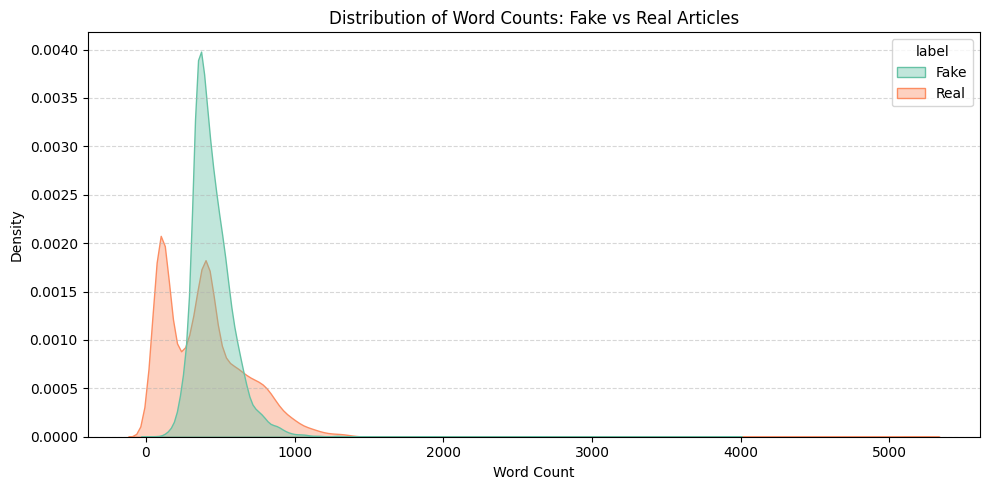

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x='word_count', hue='label', common_norm=False, fill=True, palette='Set2', alpha=0.4)

plt.title('Distribution of Word Counts: Fake vs Real Articles', fontsize=12)
plt.xlabel('Word Count', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer



In [19]:
df['clean_text'] = df['Text']
lowered = df['clean_text'].str.lower()
df['clean_text'] = lowered
print(df['clean_text'])

0        top trump surrogate brutally stabs him in the...
1       u.s. conservative leader optimistic of common ...
2       trump proposes u.s. tax overhaul, stirs concer...
3        court forces ohio to allow millions of illega...
4       democrats say trump agrees to work on immigrat...
                              ...                        
9895     wikileaks admits to screwing up immensely wit...
9896    trump consults republican senators on fed chie...
9897    trump lawyers say judge lacks jurisdiction for...
9898     watch: right-wing pastor falsely credits trum...
9899     sean spicer hilariously branded as chickensh*...
Name: clean_text, Length: 9865, dtype: object


In [20]:
import string
df['clean_text'] = df['clean_text'].str.translate(str.maketrans('', '', string.punctuation))

print(df['clean_text'])

0        top trump surrogate brutally stabs him in the...
1       us conservative leader optimistic of common gr...
2       trump proposes us tax overhaul stirs concerns ...
3        court forces ohio to allow millions of illega...
4       democrats say trump agrees to work on immigrat...
                              ...                        
9895     wikileaks admits to screwing up immensely wit...
9896    trump consults republican senators on fed chie...
9897    trump lawyers say judge lacks jurisdiction for...
9898     watch rightwing pastor falsely credits trump ...
9899     sean spicer hilariously branded as chickensht...
Name: clean_text, Length: 9865, dtype: object


In [21]:
from nltk.tokenize import word_tokenize 

df['tokens'] = df['clean_text'].apply(word_tokenize)

print(df['tokens'])

0       [top, trump, surrogate, brutally, stabs, him, ...
1       [us, conservative, leader, optimistic, of, com...
2       [trump, proposes, us, tax, overhaul, stirs, co...
3       [court, forces, ohio, to, allow, millions, of,...
4       [democrats, say, trump, agrees, to, work, on, ...
                              ...                        
9895    [wikileaks, admits, to, screwing, up, immensel...
9896    [trump, consults, republican, senators, on, fe...
9897    [trump, lawyers, say, judge, lacks, jurisdicti...
9898    [watch, rightwing, pastor, falsely, credits, t...
9899    [sean, spicer, hilariously, branded, as, chick...
Name: tokens, Length: 9865, dtype: object


In [22]:
stop_words = set(stopwords.words('english'))
df['filtered'] = [
    [word for word in row_tokens if word.lower() not in stop_words]
    for row_tokens in df['tokens']
]
print(df['filtered'])

0       [top, trump, surrogate, brutally, stabs, back,...
1       [us, conservative, leader, optimistic, common,...
2       [trump, proposes, us, tax, overhaul, stirs, co...
3       [court, forces, ohio, allow, millions, illegal...
4       [democrats, say, trump, agrees, work, immigrat...
                              ...                        
9895    [wikileaks, admits, screwing, immensely, twitt...
9896    [trump, consults, republican, senators, fed, c...
9897    [trump, lawyers, say, judge, lacks, jurisdicti...
9898    [watch, rightwing, pastor, falsely, credits, t...
9899    [sean, spicer, hilariously, branded, chickensh...
Name: filtered, Length: 9865, dtype: object


trump        37199
donald        7615
people        6996
president     6533
said          6413
would         5687
one           5595
via           4813
like          4802
image         4713
even          4351
white         4252
obama         3562
house         3440
us            3359
also          3285
time          3237
images        3113
get           3041
going         3002
dtype: int64


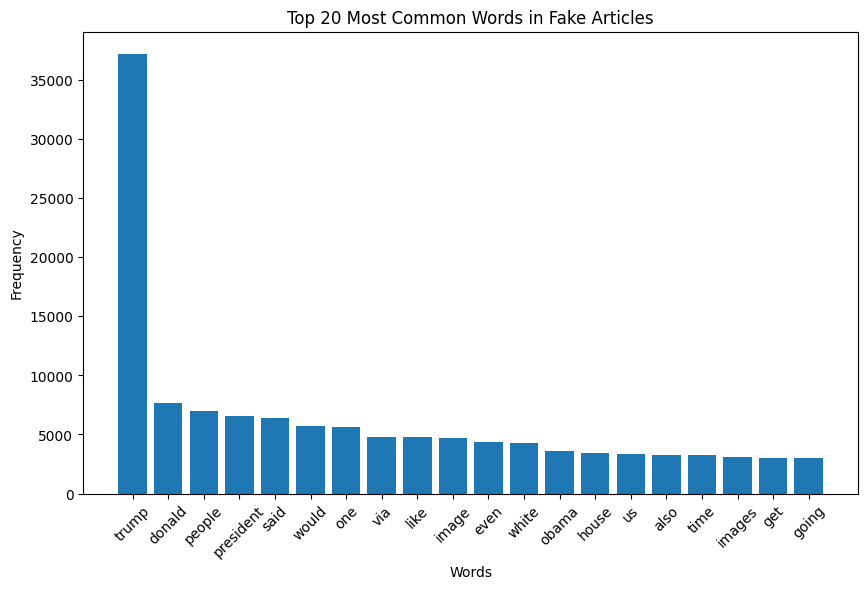

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

fake_articles = df[df['label'] == 'Fake']['filtered'].apply(' '.join)


fake_vector = CountVectorizer()

fake_matrix = fake_vector.fit_transform(fake_articles)

fake_df = pd.DataFrame(
    fake_matrix.toarray(),
    columns=fake_vector.get_feature_names_out()
)

word_counts = fake_df.sum().sort_values(ascending=False)

top20 = word_counts.head(20)

print(top20)

plt.figure(figsize=(10, 6))
plt.bar(top20.index, top20.values)

plt.title('Top 20 Most Common Words in Fake Articles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

said              22442
trump             21597
us                14791
president          9019
would              8959
house              8520
reuters            6161
republican         5643
tax                5486
senate             5287
washington         4973
white              4570
states             4262
state              4151
bill               4120
new                4002
donald             3893
also               3806
administration     3605
could              3567
dtype: int64


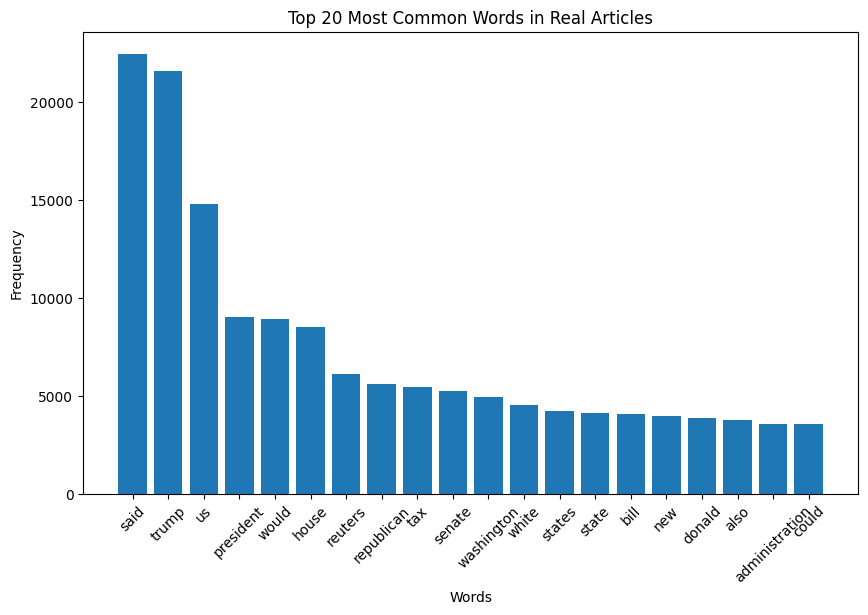

In [24]:
real_articles = df[df['label'] == 'Real']['filtered'].apply(' '.join)
real_vector = CountVectorizer()

real_matrix = real_vector.fit_transform(real_articles)

real_df = pd.DataFrame(
    real_matrix.toarray(),
    columns=real_vector.get_feature_names_out()
)

word_counts = real_df.sum().sort_values(ascending=False)

top20 = word_counts.head(20)

print(top20)

plt.figure(figsize=(10, 6))
plt.bar(top20.index, top20.values)

plt.title('Top 20 Most Common Words in Real Articles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

Key EDA Findings & Data Hygiene Summary 

1. Target Class Balance:
   - Distribution: 50.68% Fake vs. 49.32% Real.
   - Conclusion: The target variable is well-balanced, allowing standard classification metrics (Accuracy, Macro F1) to be reliably applied.

2. Article Length Analysis:
   - Fake Articles Mean Word Count: 449 words
   - Real Articles Mean Word Count: 395 words
   - Observation: Fake articles trend longer on average than real news coverage.

3. Term Frequency Discrepancies:
   - Real News: Heavily dominated by reporting verbs (e.g. 'said').
   - Fake News: Frequently centers around key political entities (e.g. 'trump').
   - Observation: Key term frequencies differ noticeably in magnitude across classes despite partial overlap in general vocabulary.

4. Data Quality Interventions:
   - Missing Values: 0 missing entries detected.
   - Duplicate Handling: 35 duplicate rows identified and purged prior to model splitting to prevent data leakage.
